# Defining Custom MCDA Methods

VISTA can work with any callable that follows a simple interface — you don't have to pick from the built-in methods. This notebook shows three levels of integration:

1. **A plain function** — the fastest way to prototype a new idea.
2. **A function with tuneable parameters** — compare behaviour under different settings.
3. **A full `MethodAdapter`** — register the method so it is discoverable by name.

In [1]:
%matplotlib inline

In [2]:
import numpy as np
from mcda_vista import generate_vista, plot_vista, plot_vista_comparison, Relation, VistaResult
from mcda_vista.methods import register_method, list_methods, get_method
from mcda_vista.methods.base import MethodAdapter

## 1. Simple Custom Callable

The minimal interface that `generate_vista` accepts is:

```python
def my_method(dataset: np.ndarray, weights: np.ndarray, **params) -> Relation:
    ...
```

where:

- `dataset[0]` — the **reference** alternative (1-D array of criterion values),
- `dataset[1]` — the **test point** being evaluated,
- `weights` — the criteria weight vector,
- `**params` — any extra keyword arguments forwarded from `generate_vista()`.

The function must return one of `Relation.BETTER`, `Relation.WORSE`, `Relation.INDIFFERENT`, or `Relation.INCOMPARABLE`.

Below is a simple weighted-sum comparison: compute a score for each alternative and compare them.

In [3]:
def simple_weighted_sum(dataset, weights, **params):
    """Weighted-sum comparison with an indifference threshold."""
    delta = params.get("delta", 0.05)
    score_ref = np.dot(dataset[0], weights)
    score_test = np.dot(dataset[1], weights)
    diff = score_test - score_ref
    if abs(diff) < delta:
        return Relation.INDIFFERENT
    return Relation.BETTER if diff > 0 else Relation.WORSE

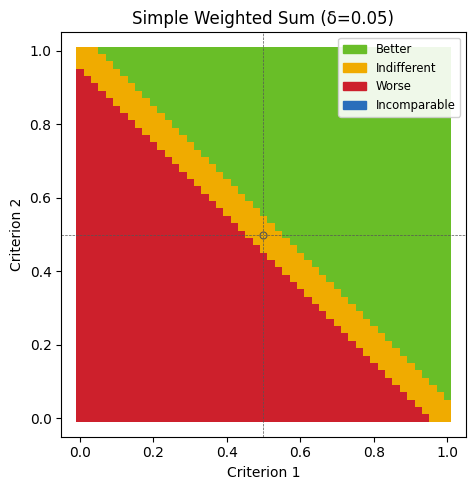

In [5]:
result_wsum = generate_vista(simple_weighted_sum, resolution=51, delta=0.05, progress=False)

fig = plot_vista(result_wsum, title="Simple Weighted Sum (δ=0.05)", point_size=27)

That's it — any function matching the interface works out of the box.

## 2. Custom Method with Parameters

Extra keyword arguments passed to `generate_vista()` are forwarded straight to your callable, so you can expose tuneable parameters with no extra plumbing.

The method below uses the **Chebyshev distance** (L∞ norm) to the ideal point `[1, 1, …]`. A lower distance means a better alternative.

In [6]:
def chebyshev_method(dataset, weights, **params):
    """Compare alternatives by weighted Chebyshev distance to the ideal."""
    delta = params.get("delta", 0.05)
    ref, test = dataset[0], dataset[1]
    dist_ref = np.max(np.abs(weights * (1.0 - ref)))
    dist_test = np.max(np.abs(weights * (1.0 - test)))
    diff = dist_ref - dist_test  # lower distance = better
    if abs(diff) < delta:
        return Relation.INDIFFERENT
    return Relation.BETTER if diff > 0 else Relation.WORSE

Generate VISTAs for several delta values and compare them side by side:

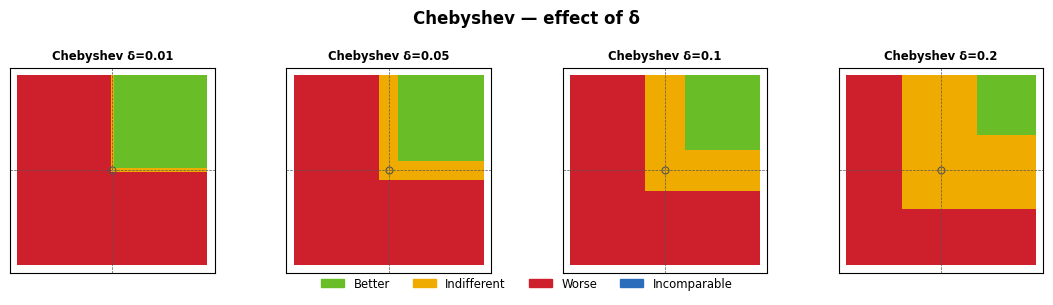

In [8]:
deltas = [0.01, 0.05, 0.10, 0.20]

results_cheb = []
for d in deltas:
    r = generate_vista(chebyshev_method, resolution=51, delta=d, progress=False)
    # Override method_name for subplot titles
    r.method_name = f"Chebyshev δ={d}"
    results_cheb.append(r)

fig = plot_vista_comparison(results_cheb, ncols=4, title="Chebyshev — effect of δ", point_size=5)

As δ grows, the indifferent region widens — exactly what you'd expect from a threshold parameter.

## 3. Registering as a MethodAdapter

For methods you intend to reuse across experiments, wrap them in a class that satisfies the `MethodAdapter` protocol and decorate it with `@register_method`. This adds:

- **Discoverability** — the method shows up in `list_methods()` and can be looked up by name.
- **Default parameters** — `default_params()` provides sensible defaults.
- **Parameter metadata** — `param_space()` describes ranges and labels for UI sliders and parameter sweeps.

In [9]:
@register_method("chebyshev")
class ChebyshevAdapter:
    name = "chebyshev"
    display_name = "Chebyshev"

    def evaluate(self, dataset, weights, **params):
        delta = params.get("delta", 0.05)
        ref, test = dataset[0], dataset[1]
        dist_ref = np.max(np.abs(weights * (1.0 - ref)))
        dist_test = np.max(np.abs(weights * (1.0 - test)))
        diff = dist_ref - dist_test
        if abs(diff) < delta:
            return Relation.INDIFFERENT
        return Relation.BETTER if diff > 0 else Relation.WORSE

    def default_params(self):
        return {"delta": 0.05}

    def param_space(self):
        return {
            "delta": {
                "min": 0.0,
                "max": 0.5,
                "default": 0.05,
                "step": 0.01,
                "label": "δ (indifference)",
            },
        }

In [10]:
# Verify registration
print("Registered:", "chebyshev" in list_methods())

adapter = get_method("chebyshev")
print("Display name:", adapter.display_name)
print("Defaults:    ", adapter.default_params())
print("Param space: ", adapter.param_space())

Registered: True
Display name: Chebyshev
Defaults:     {'delta': 0.05}
Param space:  {'delta': {'min': 0.0, 'max': 0.5, 'default': 0.05, 'step': 0.01, 'label': 'δ (indifference)'}}


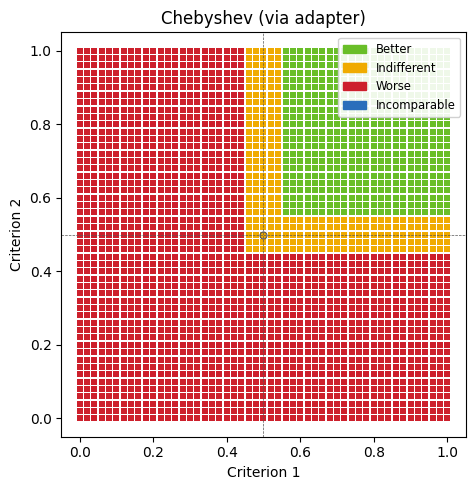

In [13]:
# Now usable by name, just like built-in methods
result_adapter = generate_vista("chebyshev", resolution=51, progress=False)

fig = plot_vista(result_adapter, title="Chebyshev (via adapter)", point_size=25)

## 4. Comparing Custom vs Built-in Methods

Once registered, custom methods slot seamlessly into `plot_vista_comparison` alongside built-in ones:

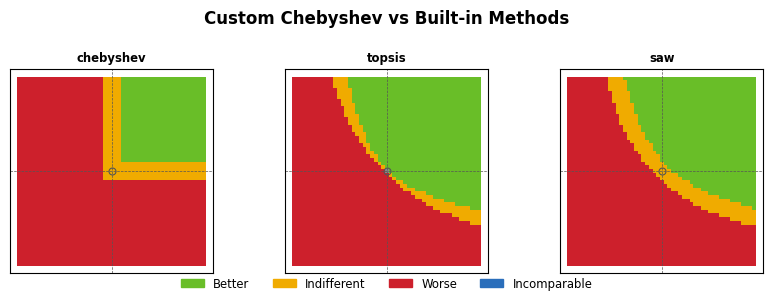

In [14]:
methods = ["chebyshev", "topsis", "saw"]

results_cmp = [generate_vista(m, resolution=51, progress=False) for m in methods]

fig = plot_vista_comparison(
    results_cmp,
    ncols=3,
    title="Custom Chebyshev vs Built-in Methods",
    point_size=5
)

## Summary

| Integration level | What you write | What you get |
|---|---|---|
| **Plain callable** | `def f(dataset, weights, **params) -> Relation` | Works with `generate_vista(f, ...)` immediately |
| **MethodAdapter class** | A class with `evaluate`, `default_params`, `param_space` | Discoverable by name via `generate_vista("key", ...)`, parameter metadata for sweeps and UIs |

Start with a plain function while prototyping. When the method is stable, promote it to a `MethodAdapter` and register it.